In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Project Objective
Predict whether a Titanic passenger survived using passenger information such as as age, sex, ticket class, fare, family relationships, and embarkation port.

## Prediction Type - Classification
Predict for Survival, where 0 means did not survived and 1 means survived.

## Initial Evaluation Metrics
Accuracy, Precision, Recall, and F1 Score

# Data Inspection

In [3]:
df = pd.read_csv('data/train.csv')

In [4]:
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Dooley, Mr. Patrick",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


## Summary: DataFrame Dimensions, Missing Value Counts, ,Possible Identifiers, Target

- Create dataframe where the index are the column heads, and columns are missing count and missing percentage. Only include columns (from the original dataframe) with missing values and sort them in descending order by the missing percentage

In [7]:
#Rows and columns
rows, columns = df.shape

# Target column
target_columns = 'Survived'

# Categorical columns
categorical_columns = ['Pclass', 'Sex', 'Embarked']

# Numerical columns
numerical_columns = ['Age', 'Fare', 'SibSp', 'Parch']

# Text-like columns
text_like_columns = ['Name', 'Ticket', 'Cabin']

# Identifier columns
identifier_columns = 'PassengerId'

df_missing = pd.DataFrame({
    'Missing_cnt': df.isnull().sum(),
    '% Missing': ((df.isnull().sum() / df.shape[0]) * 100).round(2)
}, index=df.columns)

df_missing_final = df_missing[df_missing['Missing_cnt'] > 0].sort_values(
    by='% Missing', 
    ascending=False)
print('Total Rows:', rows)
print('Total Columns:', columns)
print('Numerical Columns:', numerical_columns)
print('Categorical Columns:', categorical_columns)
print('Text-like Columns:', text_like_columns)
print('Identifier Columns:', identifier_columns)
print(df_missing_final)

Total Rows: 891
Total Columns: 12
Numerical Columns: ['Age', 'Fare', 'SibSp', 'Parch']
Categorical Columns: ['Pclass', 'Sex', 'Embarked']
Text-like Columns: ['Name', 'Ticket', 'Cabin']
Identifier Columns: PassengerId
          Missing_cnt  % Missing
Cabin             687      77.10
Age               177      19.87
Embarked            2       0.22


# Summary of Columns
| Name of column | Meaning of column | Initial concern |
|---|---|---|
| PassengerId | Unique row identifier | Probably not meaningful for prediction |
| Survived | Whether the passenger survived: 0 = no, 1 = yes | This is the target column we want to predict |
| Pclass | Passenger ticket class: 1 = upper, 2 = middle, 3 = lower | Represents social and economic status |
| Name | Passenger name | Contains title information |
| Sex | Passenger sex | Likely important |
| Age | Passenger age | Has missing values |
| SibSp | Number of siblings or spouses aboard | May be useful as family-size information |
| Parch | Number of parents or children aboard | May be useful as family-size information |
| Ticket | Ticket number | High cardinality |
| Fare | Ticket fare price | Skewed and possibly shared |
| Cabin | Cabin number | Mostly missing |
| Embarked | Port where passenger boarded | Small Number of Missing Values |

# Check for obvious data quality issues

- Exact Duplicate Rows, Duplicate IDs
- Invalid Target Values
- Invalid Passenger Class Values
- Duplicate Names, Missing Names, or Extra Spaces
- Invalid Sex
- Impossible Ages
- Unusually Large SibSp counts
- Unusually Large Parch counts
- Unusually Large Total Family Size
- Duplicate Tickets, Blank Tickets
- Negative Fares, Zero Fares, Extreme High Fares
- Missing Cabin Values and Rows with Multiple Cabins
- Missing and Invalid Embarked Values

In [8]:
#Exact duplicate rows
duplicate_rows = df[df.duplicated()]
print('Duplicated rows:', duplicate_rows.shape[0])
display(duplicate_rows)


Duplicated rows: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [9]:
#Duplicate IDs, Min/Max PassengerID, Unique Passenger IDs
print("Duplicate PassengerId:", df["PassengerId"].duplicated().sum())
print("Min PassengerId:", df["PassengerId"].min())
print("Max PassengerId:", df["PassengerId"].max())
print("Unique PassengerId:", df["PassengerId"].nunique())

Duplicate PassengerId: 0
Min PassengerId: 1
Max PassengerId: 891
Unique PassengerId: 891


In [10]:
(df["Survived"].value_counts(dropna=False))

Survived
0    549
1    342
Name: count, dtype: int64

In [11]:
(df['Pclass'].value_counts(dropna=False))

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [12]:

print("Missing/blank Name:", df["Name"].isna().sum() + df["Name"].astype(str).str.strip().eq("").sum())
print("Duplicate Name:", df["Name"].duplicated().sum())
display(df[df["Name"].duplicated(keep=False)].sort_values("Name"))

Missing/blank Name: 0
Duplicate Name: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [13]:

print(df["Sex"].value_counts(dropna=False))

Sex
male      577
female    314
Name: count, dtype: int64


In [14]:
# Check for suspicious ages
impossible_age = df[(df['Age'] < 0) | (df['Age'] > 100)]
print("Impossible Age rows:", impossible_age.shape[0])
display(impossible_age)

Impossible Age rows: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [15]:
# Checking for some unusally large numbers for family members columns (not automatically wrong - just investigation)
print(df["SibSp"].value_counts(dropna=False).sort_index())
suspicious_sibsp = df[df["SibSp"] > 5]
display(suspicious_sibsp)

print(df["Parch"].value_counts(dropna=False).sort_index())
suspicious_parch = df[df["Parch"] > 5]
display(suspicious_parch)

SibSp
0    608
1    209
2     28
3     16
4     18
5      5
8      7
Name: count, dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


Parch
0    678
1    118
2     80
3      5
4      4
5      5
6      1
Name: count, dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
678,679,0,3,"Goodwin, Mrs. Frederick (Augusta Tyler)",female,43.0,1,6,CA 2144,46.9,NaN,S


In [16]:
# Ticket investigation
print("Missing/blank Ticket:", df["Ticket"].isna().sum() + df["Ticket"].astype(str).str.strip().eq("").sum())
print("Rows with shared Ticket:", df[df["Ticket"].duplicated(keep=False)].shape[0])
display(df[df["Ticket"].duplicated(keep=False)].sort_values("Ticket").head(20))

Missing/blank Ticket: 0
Rows with shared Ticket: 344


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
257,258,1,1,"Cherry, Miss. Gladys",female,30.0,0,0,110152,86.5000,B77,S
759,760,1,1,"Rothes, the Countess. of (Lucy Noel Martha Dye...",female,33.0,0,0,110152,86.5000,B77,S
504,505,1,1,"Maioni, Miss. Roberta",female,16.0,0,0,110152,86.5000,B79,S
262,263,0,1,"Taussig, Mr. Emil",male,52.0,1,1,110413,79.6500,E67,S
558,559,1,1,"Taussig, Mrs. Emil (Tillie Mandelbaum)",female,39.0,1,1,110413,79.6500,E67,S
585,586,1,1,"Taussig, Miss. Ruth",female,18.0,0,2,110413,79.6500,E68,S
110,111,0,1,"Porter, Mr. Walter Chamberlain",male,47.0,0,0,110465,52.0000,C110,S
475,476,0,1,"Clifford, Mr. George Quincy",male,NaN,0,0,110465,52.0000,A14,S
523,524,1,1,"Hippach, Mrs. Louis Albert (Ida Sophia Fischer)",female,44.0,0,1,111361,57.9792,B18,C
329,330,1,1,"Hippach, Miss. Jean Gertrude",female,16.0,0,1,111361,57.9792,B18,C


In [17]:
# Check ticket fares - negative, zeros, high fares
negative_fare = df[df['Fare'] < 0]
zero_fare = df[df['Fare'] == 0]

print("Negative Fare rows:", negative_fare.shape[0])
print("Zero Fare rows:", zero_fare.shape[0])
print(df["Fare"].describe())

display(zero_fare)

Negative Fare rows: 0
Zero Fare rows: 15
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
179,180,0,3,"Leonard, Mr. Lionel",male,36.0,0,0,LINE,0.0,NaN,S
263,264,0,1,"Harrison, Mr. William",male,40.0,0,0,112059,0.0,B94,S
271,272,1,3,"Tornquist, Mr. William Henry",male,25.0,0,0,LINE,0.0,NaN,S
277,278,0,2,"Parkes, Mr. Francis ""Frank""",male,NaN,0,0,239853,0.0,NaN,S
302,303,0,3,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,LINE,0.0,NaN,S
413,414,0,2,"Cunningham, Mr. Alfred Fleming",male,NaN,0,0,239853,0.0,NaN,S
466,467,0,2,"Campbell, Mr. William",male,NaN,0,0,239853,0.0,NaN,S
481,482,0,2,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,239854,0.0,NaN,S
597,598,0,3,"Johnson, Mr. Alfred",male,49.0,0,0,LINE,0.0,NaN,S
633,634,0,1,"Parr, Mr. William Henry Marsh",male,NaN,0,0,112052,0.0,NaN,S


In [18]:
# Missing Cabin Values and rows with multiple cabin
missing_cabin = df['Cabin'].isna().sum()
multiple_cabins = df[df['Cabin'].notna() & df['Cabin'].astype(str).str.contains(' ')]
print("Missing Cabin:", missing_cabin)
print("% Missing Cabin:", round(missing_cabin / len(df) * 100, 2))
print("Multiple Cabin rows:", multiple_cabins.shape[0])
display(multiple_cabins[["PassengerId", "Cabin"]].head(20))

Missing Cabin: 687
% Missing Cabin: 77.1
Multiple Cabin rows: 24


,PassengerId,Cabin
27,28,C23 C25 C27
75,76,F G73
88,89,C23 C25 C27
97,98,D10 D12
118,119,B58 B60
128,129,F E69
297,298,C22 C26
299,300,B58 B60
305,306,C22 C26
311,312,B57 B59 B63 B66


In [19]:
# Missing and Invalid Embarked Values
print(df["Embarked"].value_counts(dropna=False))

Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64


# Data Quality Summary

- **Dataset size:** 891 rows and 12 columns.

- **Duplicate rows:** No full duplicate rows were found.
  - **Action:** No duplicate-row cleanup needed.

- **PassengerId:** No duplicate IDs were found.
  - **Action:** Keep for row tracking, but do not use as a prediction feature.

- **Age:** 177 missing values, about 19.87% of rows.

- **Cabin:** 687 missing values, about 77.10% of rows.

- **Embarked:** 2 missing values, about 0.22% of rows.
  - **Action:** Fill missing values with the most common value.

- **Ticket:** 344 rows share a ticket value with another row.
  - **Action:** Do not use raw `Ticket` at first. It is messy text-like data.

- **Fare:** 15 rows have a fare of `0`.
  - **Action:** Inspect these rows. Keep them unless they are clearly incorrect.

- **SibSp and Parch:** 7 rows have very large family size, greater than 8.
  - **Action:** Inspect these rows. Keep them unless they are clearly incorrect.

- **Survived, Pclass, and Sex:** No obvious invalid categories were found.
  - **Action:** Use these columns normally after basic cleaning.

- **Main modeling concerns:** Missing `Age`, very missing `Cabin`, and messy text-like columns such as `Name`, `Ticket`, and `Cabin`.

# Explanatory Data Analysis
1) Target Distribution
2) Univariate Analysis - Numerical and Categorical Variables
3) Bivariate Analysis
4) Family structure -
investigate whether travelling alone or with familt might affect survival
5) Write hypothesis for modelling

### 1) Target Distribution - Survived vs Did Not Survive

In [20]:
survival_counts = df['Survived'].value_counts().sort_index()
survival_counts

Survived
0    549
1    342
Name: count, dtype: int64

The bar graph counts the number of Survived vs Did Not Survived Passengers
The pie chat displays the percentages

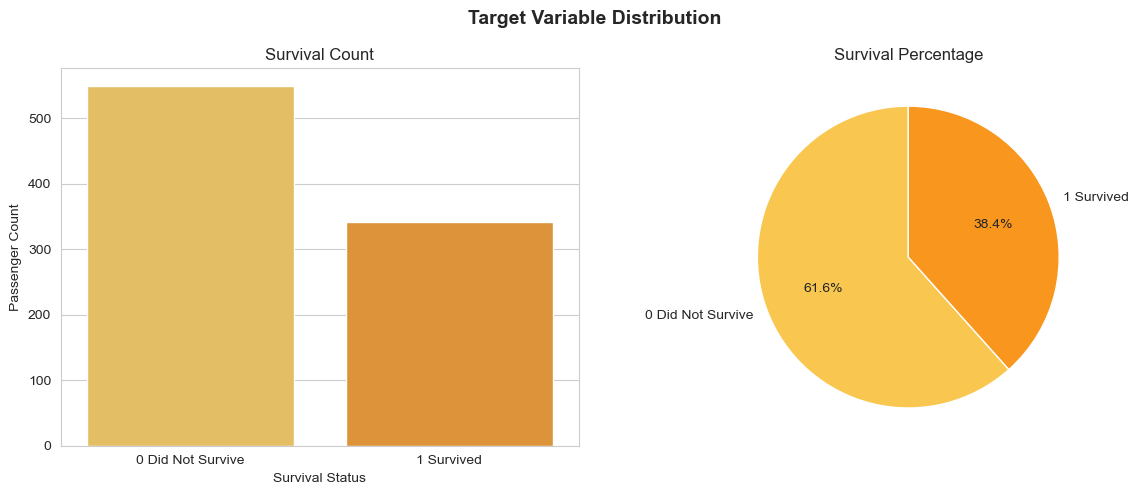

In [21]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5)) #standard use

survival_label = ['0 Did Not Survive', '1 Survived']
colors = ["#F9C74F", "#F8961E"]

# Bar chart
sns.barplot(x = survival_label, y = survival_counts.values, 
            ax = axes[0], palette = colors)
axes[0].set_title("Survival Count")
axes[0].set_xlabel("Survival Status")
axes[0].set_ylabel("Passenger Count")

# Pie Chart
axes[1].pie(
    survival_counts.values,
    labels= survival_label,
    autopct="%1.1f%%",
    startangle=90,
    colors = colors
)
axes[1].set_title("Survival Percentage")


plt.suptitle("Target Variable Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Univariate Analysis 

### Numerical Features
4 histograms for Age, Fare, SibSp, and Parch distributions
1) Distribution plots use -> *sns.histplot(data, x, bins, kde, ax, color)*
2) Value Labeling: *axes[i].axvline(value, color, linestyle, linewidth, label)*: Line to label values on our plots

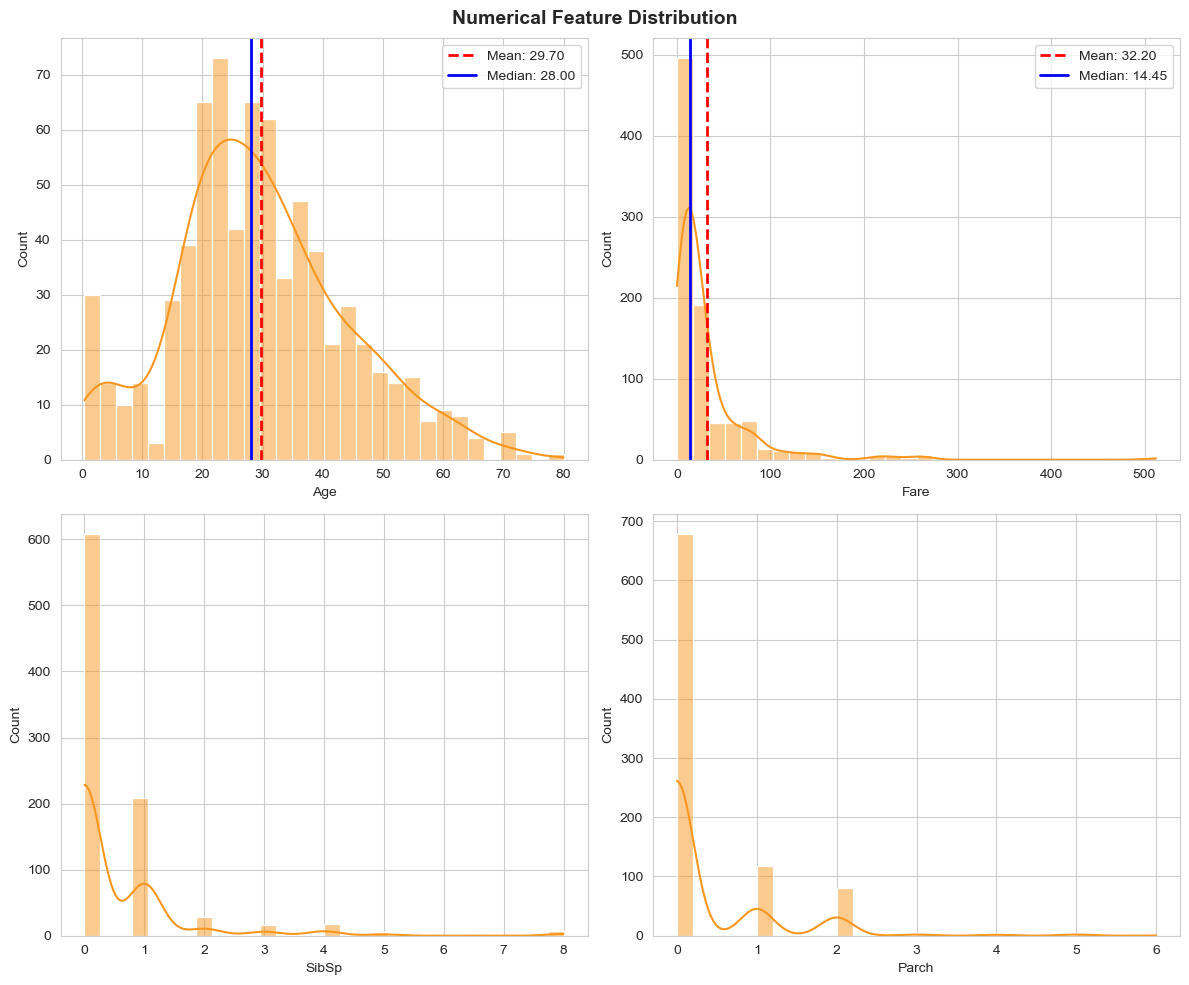

In [22]:
fig, axes = plt.subplots(2, 2, figsize = (12, 10))
axes = axes.flatten() # Converts 2d indexing to 2d indexing

for i, col in enumerate(numerical_columns):
    sns.histplot(df, x=col, bins = 30, kde = True, ax = axes[i], color="#F8961E")
    axes[i].set_label(f'{col} Distibution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    
    # Add mean and median lines for Age and Fare plots
    if col in ['Age', 'Fare']:
        mean_value = df[col].mean()
        median_value = df[col].median()
        
        axes[i].axvline(
            mean_value,
            color="red",
            linestyle="--",
            linewidth=2,
            label=f"Mean: {mean_value:.2f}"
        )
        
        axes[i].axvline(
            median_value,
            color="blue",
            linestyle="-",
            linewidth=2,
            label=f"Median: {median_value:.2f}"
        )
        
        axes[i].legend()
    
fig.suptitle('Numerical Feature Distribution', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()
    


*Disclosed Patterns*
- Age: Doesn't show much skewness (fairly spreaded out).
- Fare: Right skewed -> Most are low but few are very high.

For each feature, we will determine the outliers (values that lie below LB and above UB)
- *IQR = Q3 - Q1*
- *Lower bound = Q1 - 1.5 * IQR*
- *Upper bound = Q3 + 1.5 * IQR*\
*Important plotting tools*
1) Outlier exploration use -> sns.boxplot(data, x, ax, color)

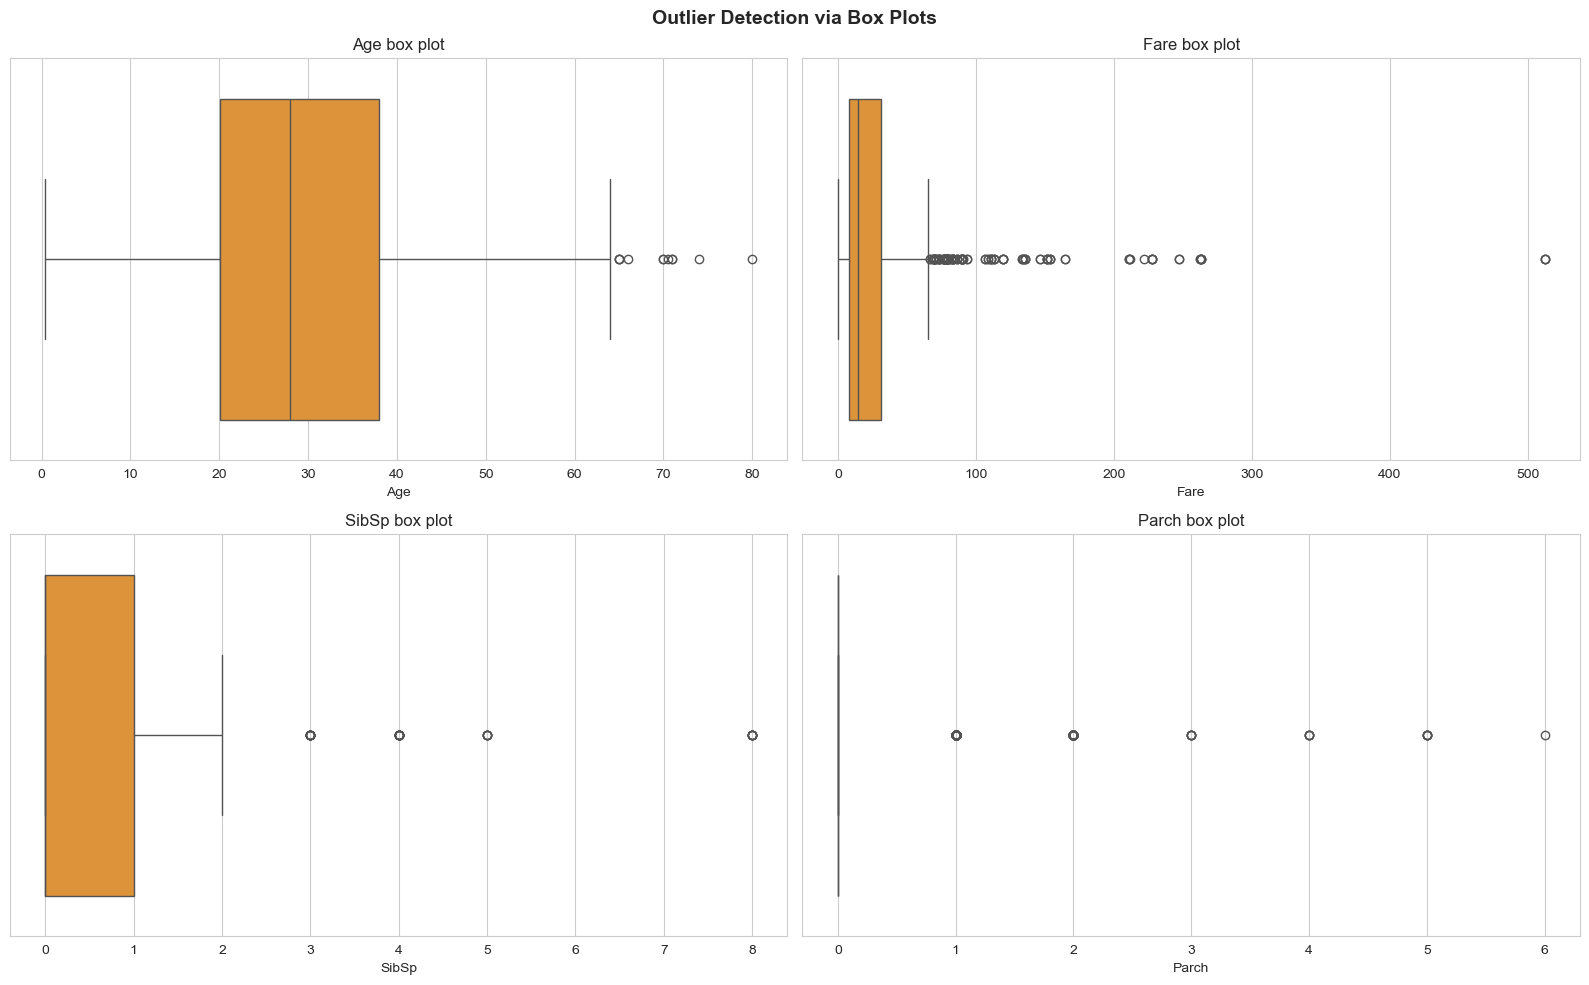

In [23]:
fig, axes = plt.subplots(2, 2, figsize = (16, 10))
axes = axes.flatten()
for i, col in enumerate(numerical_columns):
    sns.boxplot(data = df, x = col, ax = axes[i], color="#F8961E")
    axes[i].set_title(f'{col} box plot')
plt.suptitle("Outlier Detection via Box Plots", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
    

### Categorical Features
- Inspect categories - Categorical feature distribution
1) Category counting use -> countplot(data, x, ax, color, order)*: Bar chart for category count
2) In-figure value labeling -> axes[i].containers and bar_label(containers)
3) .value_counts() ->  returns a series containing counts of different values in descending order
4) .value_counts().index -> returns the list containing the unqiue instances -> index from the series


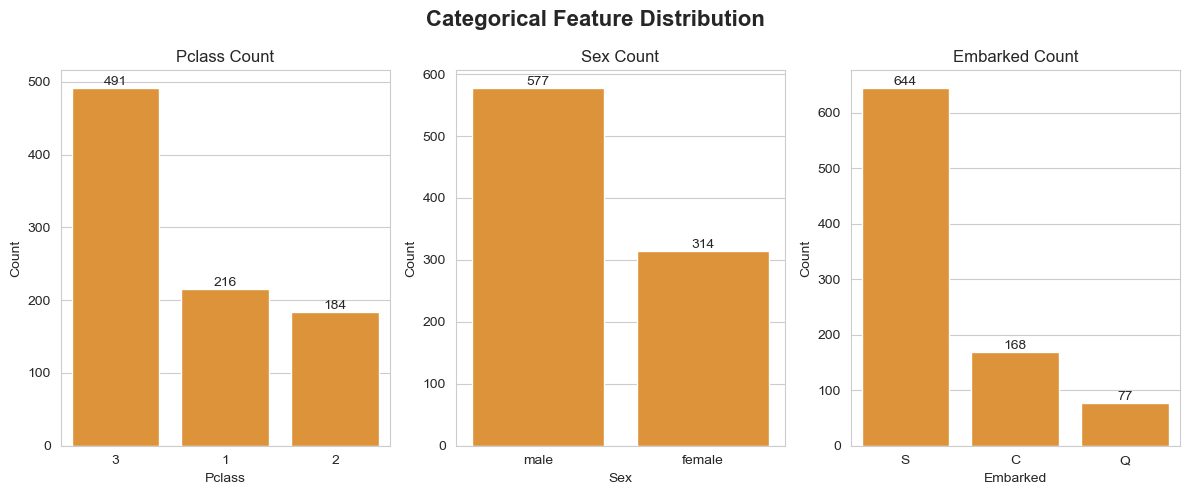

In [24]:
# Categorical feature distribution
fig, axes = plt.subplots(1, 3, figsize = (12, 5))
axes = axes.flatten()
for i, col in enumerate(categorical_columns):
    sns.countplot(data = df, x = col, ax = axes[i], color="#F8961E", order = df[col].value_counts().index)
    axes[i].set_title(f'{col} Count')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    for container in axes[i].containers:
        axes[i].bar_label(container)
plt.suptitle("Categorical Feature Distribution", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## Bivariate Analysis

### Survival by categorical features

### Figure 1
sns.countplot(hue) -> For each category in each categorical feature, we want to determine # and percentages of people Who Survived and Did Not Survive. 
- df.groupby([col, "Survived"]): Group data by two things
- .size(): Counts the number rows in each group
- .unstack(fill_value = 0) Turns the survived values (0, 1), which is currently a row in our group by table, into a column and if a group does not exist, put 0 instead of missing
- reindex(category_order) Makes sure the table row follows the same order as the plot
- .sum(axis=1) adds across rows
- div(....,axis=0) divides each row by its row total

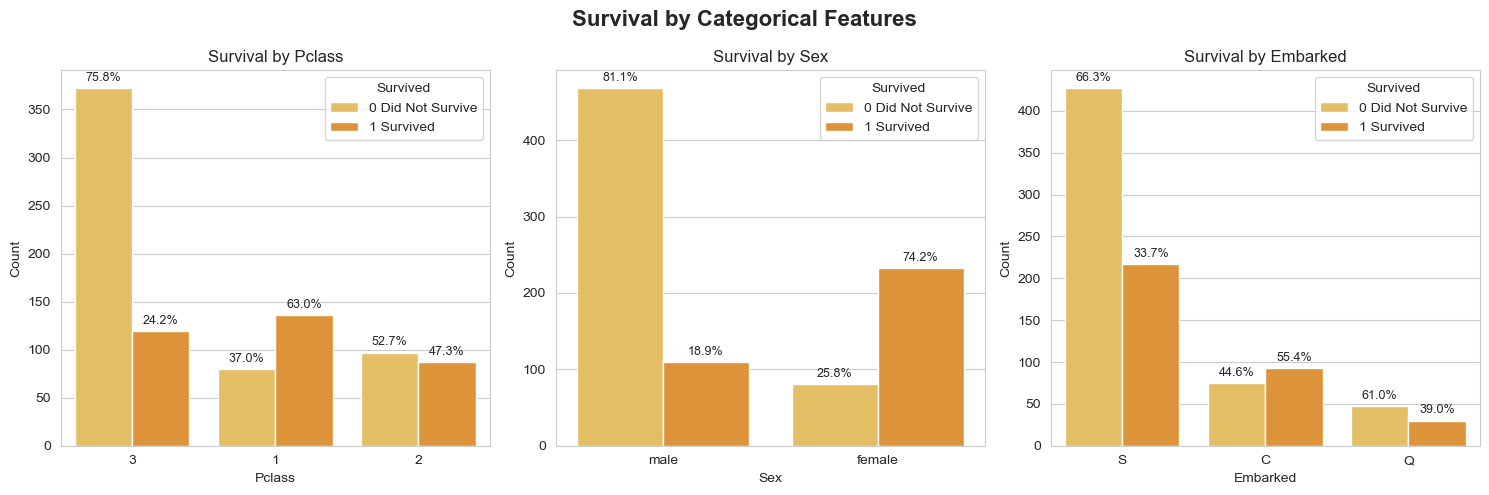

In [36]:
# Figure 1
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

# Color palette for survival groups
survival_palette = {
    0: "#F9C74F",  # Not survived
    1: "#F8961E"   # Survived
}

for i, col in enumerate(categorical_columns):
    sns.countplot(
        data=df,
        x=col,
        hue="Survived", #bivariate feature
        ax=axes[i],
        palette=survival_palette,
        order=df[col].value_counts().index
    )

    axes[i].set_title(f"Survival by {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].legend(title="Survived", labels=["0 Did Not Survive", "1 Survived"])

    # Calculate survival percentages within each category by creating a percentage table
    category_order = df[col].value_counts().index
    count_table = df.groupby([col, "Survived"]).size().unstack(fill_value=0).reindex(category_order)
    percent_table = count_table.div(count_table.sum(axis = 1), axis = 0)

    # Add percentage labels on top of each bar
    for survival_value, container in zip([0, 1], axes[i].containers):
        labels = [
            f"{percent_table.loc[category, survival_value] * 100:.1f}%"
            for category in category_order
        ]

        axes[i].bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=9
        )
plt.suptitle('Survival by Categorical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Figure 2
sns.barplot() or axes[i].bar -> Investigate survival percentage across all categories in each categorical feature


In [26]:
# Figure 2
percents = df.groupby('Pclass')['Survived'].mean()
percents

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

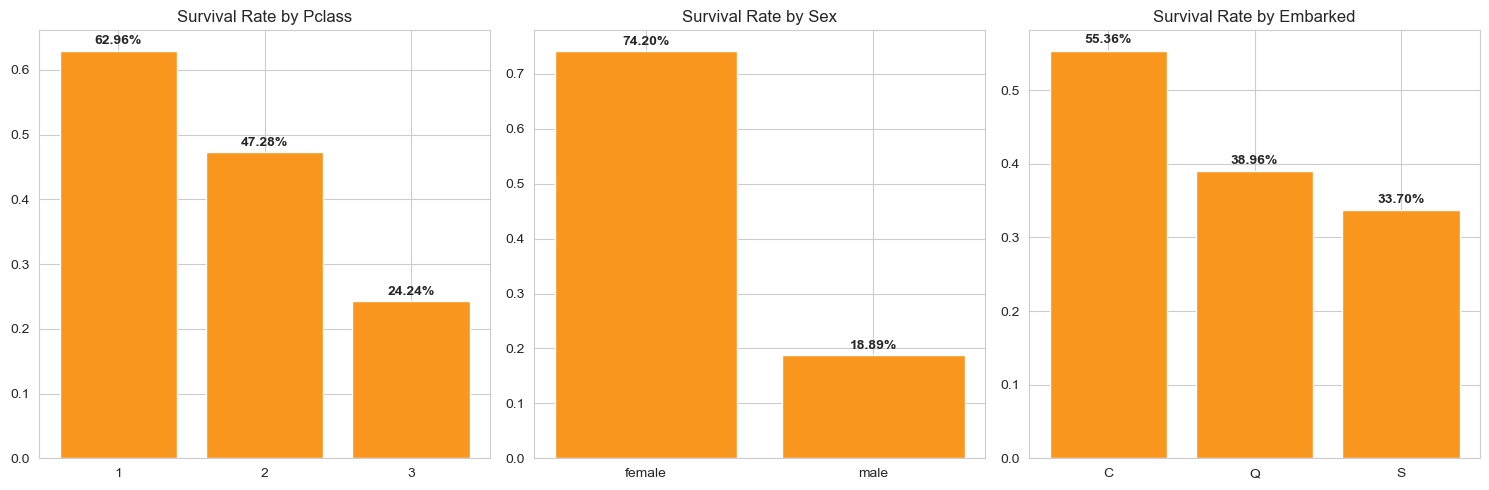

In [27]:
# Figure 2 using matplotlib
fig, axes = plt.subplots(1, 3, figsize = (15, 5))

for i, col in enumerate(categorical_columns):
    axes[i].set_title(f"Survival Rate by {col}")
    percents = df.groupby(col)['Survived'].mean()
    axes[i].bar(percents.index.astype(str), percents.values, color = "#F8961E")
    
    for j, v in enumerate(percents):
        axes[i].text(j, v + 0.01, f"{v:.2%}", ha="center", fontweight='bold')

plt.tight_layout()
plt.show()

Seaborn Alternative to figure 2\
- sns.barplot(data, x, y) -> Used for bivariate analysis
- sns.barplot(data = df, x = col, y = 'Survived') works because Survived -> 1 (True) while Did not Survive -> 0 (False). Therefore, the average of Survived becomes the survival rate.
- If Survive is not just 0 and 1, you should then first choose the specific survival category you care about and make these changes

In [37]:
#Example Case:

# Create a Target flag column -> labeled 1 if satisfied, labeled 0 if not
'''df["TargetFlag"] = (df["Survived"] == target_value).astype(int)'''

# Plotting Target flag rate
'''
for i, col in enumerate(categorical_columns):
    sns.barplot(
        data=df,
        x=col,
        y="TargetFlag",
        ax=axes[i],
        color="#F8961E",
        errorbar=None
    )
'''

'\nfor i, col in enumerate(categorical_columns):\n    sns.barplot(\n        data=df,\n        x=col,\n        y="TargetFlag",\n        ax=axes[i],\n        color="#F8961E",\n        errorbar=None\n    )\n'

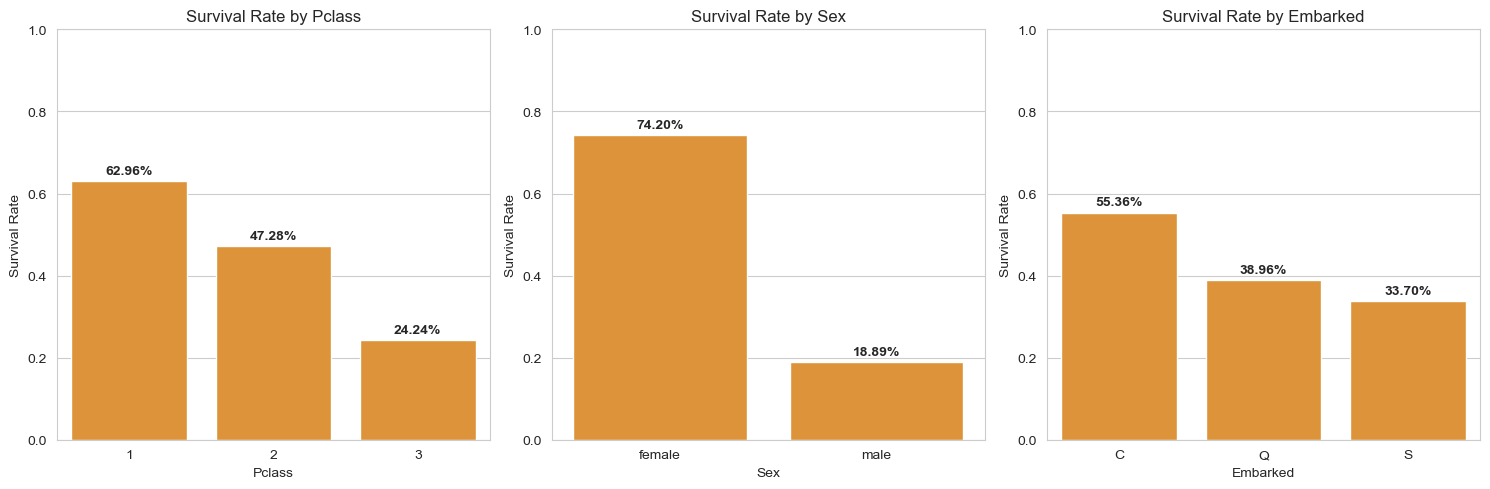

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(categorical_columns):
    sns.barplot(
        data=df,
        x=col,
        y="Survived",
        ax=axes[i],
        color="#F8961E",
        errorbar=None,
        order=df.groupby(col)["Survived"].mean().sort_values(ascending=False).index
    )

    axes[i].set_title(f"Survival Rate by {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Survival Rate")
    axes[i].set_ylim(0, 1)

    # Add percentage labels
    for container in axes[i].containers:
        axes[i].bar_label(
            container,
            labels=[f"{bar.get_height():.2%}" for bar in container],
            padding=3,
            fontweight="bold"
        )
plt.tight_layout()
plt.show()

### Figure 3
sns.barplot(df, x = 'Sex', y = 'Survived', hue = Sex) -> Survival based on Sex and PClass\
Each bar represents the survival percentage within each class and sex

In [38]:
# Figure 3 - This table displays survival rate by sex and class
survival_grouped = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()
display(survival_grouped)

Sex,female,male
Pclass,,
1,0.968085,0.368852
2,0.921053,0.157407
3,0.500000,0.135447


Interpretation: Most females in Pclass 1 and 2 survived and half survived in Pclass 3. Males showed significantly less chance of survival across 3 Pclasses

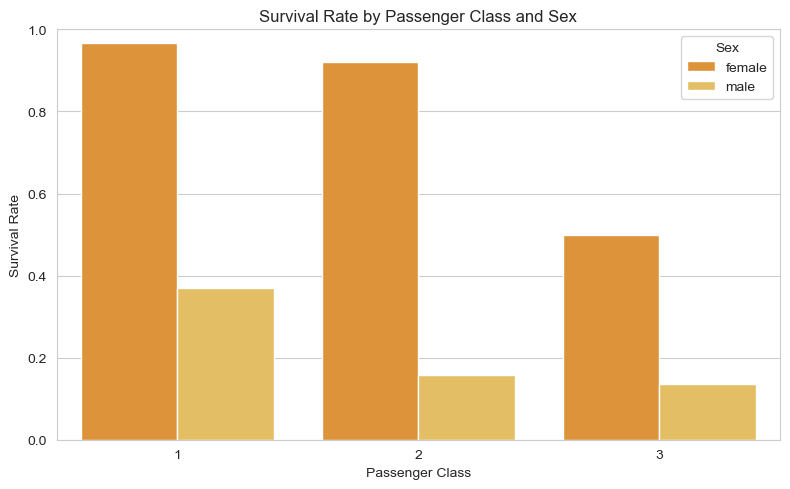

In [39]:
fig, ax = plt.subplots(figsize = (8, 5))
sns.barplot(data = df, x = 'Pclass', y = 'Survived', hue = 'Sex', ax = ax, 
            errorbar = None, palette = {
                'male': '#F9C74F',
                'female': '#F8961E'
            })
ax.set_title("Survival Rate by Passenger Class and Sex")
ax.set_xlabel("Passenger Class")
ax.set_ylabel("Survival Rate")
ax.set_ylim(0, 1)
ax.legend(title='Sex')
plt.tight_layout()
plt.show()

### Survival by Numerical Features
1) Age Distribution by Survival: Histogram with KDE/density curve
2) Fair Distribution by Survival, and Log Fare Distrbution: Violin plot with mean/median labels
3) Family Size Distribution and Survival Rate for each family size: Countplot - How many passengers are in each family size, Bar plot: Survival rate by family size

### Figure 1
- sns.histplot, sns.kdeplot() hued by Survival -> Age Distribution by Survival

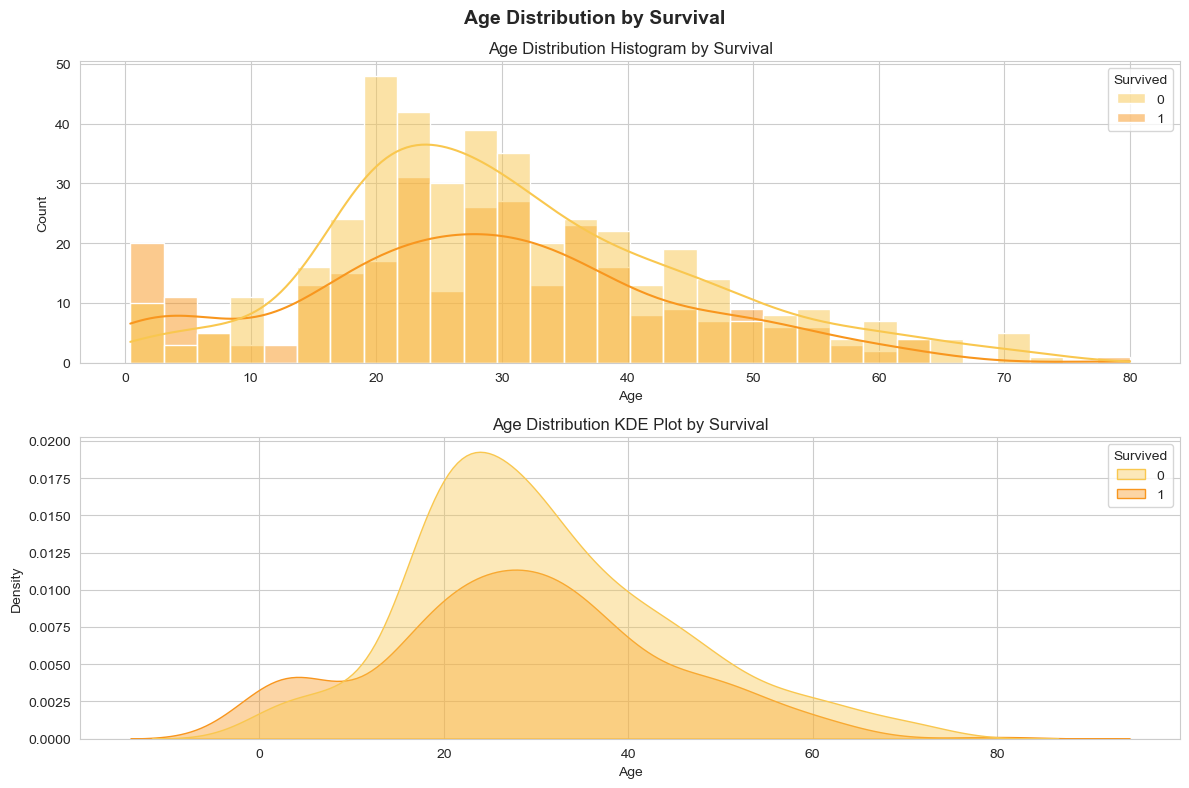

In [32]:
# Figure 1: Age Distribution by Survival
fig, axes = plt.subplots(2, 1, figsize = (12, 8))
axes = axes.flatten() # Converts 2d indexing to 2d indexing

survival_palette = {0: '#F9C74F', 1 : '#F8961E'}

# Histogram
sns.histplot(df, x='Age', hue = 'Survived', bins = 30, ax = axes[0], palette = survival_palette, kde = True)
axes[0].set_title('Age Distribution Histogram by Survival')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

#KDE plot
sns.kdeplot(df, x='Age', hue = 'Survived', ax = axes[1], palette = survival_palette, fill=True, alpha = 0.4)
axes[1].set_title("Age Distribution KDE Plot by Survival")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Density")

fig.suptitle("Age Distribution by Survival", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()


### Figure 2
- sns.violinplot(x = 'Survived', y = 'Fare') -> Fare distribution by survival
- ax.text() -> Median Value Displaying

0
1


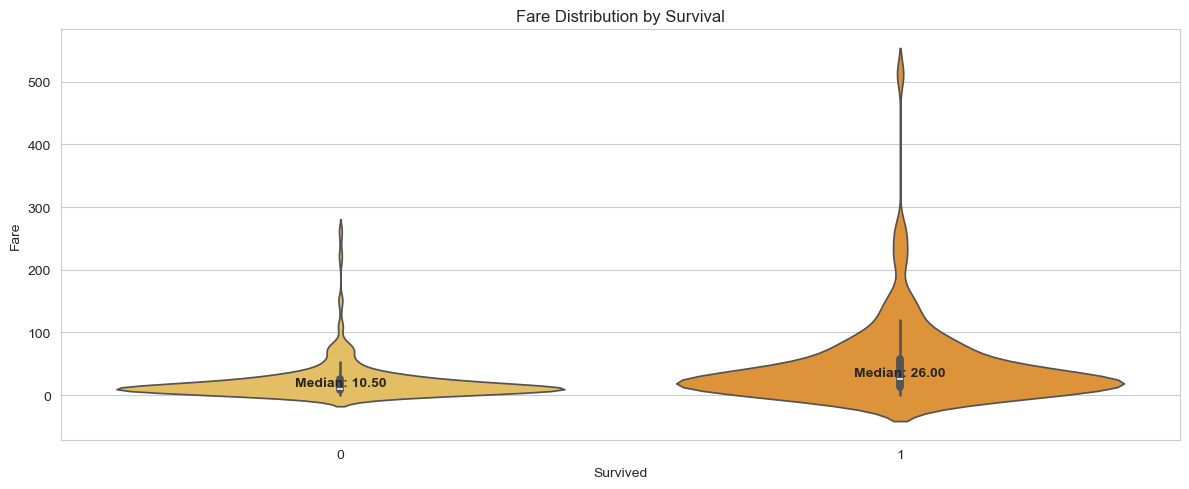

In [40]:
# Figure 2: Fare distribution by survival

fig, ax = plt.subplots(figsize=(12, 5))

# Color palette for survival groups
survival_palette = {
    '0': "#F9C74F",  # Did not survive
    '1': "#F8961E"   # Survived
}

# Violin plot
sns.violinplot(
    data=df,
    x="Survived",
    y="Fare",
    ax=ax,
    palette=survival_palette
)

ax.set_title("Fare Distribution by Survival")
ax.set_xlabel("Survived")
ax.set_ylabel("Fare")

# Calculate median fare labels
fare_medians = df.groupby('Survived')['Fare'].median()

for survival_value, median_fare in fare_medians.items():
    ax.text(
        survival_value,
        median_fare,
        f"Median: {median_fare:.2f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

### Figure 3
- sns.countplot() -> Family Size Distribution
- sns.barplot() -> Survival Rate for each family size

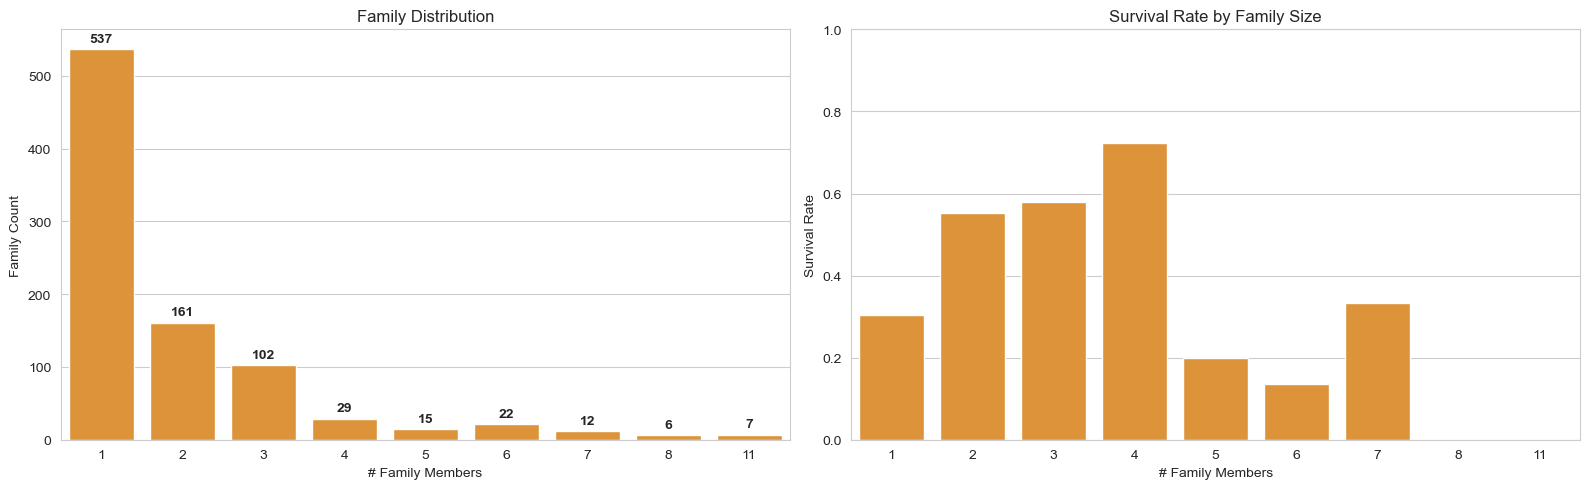

In [42]:
# Create New Family Size columns
df['Family_size'] = df['SibSp'] + df['Parch'] + 1

fig, axes = plt.subplots(1, 2, figsize = (16, 5))
axes = axes.flatten()

# Store count labels for later display
values = df['Family_size'].value_counts().sort_index().values

# Countplot for family sizes
sns.countplot(df, x = 'Family_size', ax=axes[0], color = '#F8961E'
              , order = sorted(df['Family_size'].dropna().unique()))
axes[0].set_title("Family Distribution")
axes[0].set_xlabel("# Family Members")
axes[0].set_ylabel("Family Count")

# Add the count lavels on top of each bar
for container in axes[0].containers:
    axes[0].bar_label(
        container,
        labels=values,
        padding=3,
        fontweight='bold'
    )

# Survival rate for each family size
sns.barplot(
        data=df,
        x='Family_size',
        y="Survived",
        ax=axes[1],
        color="#F8961E",
        errorbar=None,
    )

axes[1].set_title(f"Survival Rate by Family Size")
axes[1].set_xlabel('# Family Members')
axes[1].set_ylabel("Survival Rate")
axes[1].set_ylim(0, 1)


plt.tight_layout()
plt.show()



## Oberservations in a Nutshell


1) 61.6% Survived, 38.4 Did not Survive
2) Fare: Extremely Right Skewed -> Most are low but few are high
3) 577 male, 314 female passengers

- Class: People in higher classes had a higher chance of surviving (63% in Pclass1 survived, 47% in Pclass2 survived, 24.2% in Pclass 3 survived)

- Sex: Females had a higher chance of surving than males (74% of females survived, 19% of males survived)

- Age: Young children (Under 10 years) have a higher chance of survival compared to older passengers.

- Embarked: Most people embarked from port S but chance of survival was highest for those who embarked from port C. Passengers at Q were all from Pclass 3

- Parch+SibSp: Having 3-4 family members shows a greater chance of survival than being along or having a large family travelling with you

## Correlation Matrix

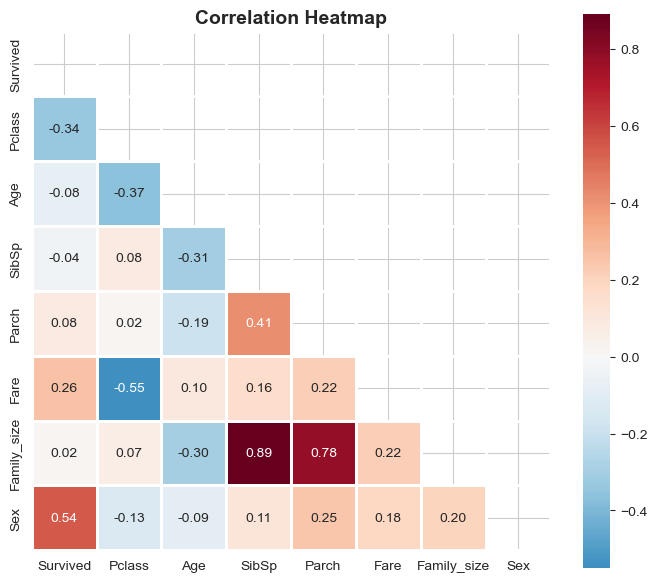

In [45]:
numeric_df = df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "Family_size"]].copy()
numeric_df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

fig, ax = plt.subplots(figsize=(7, 6))
corr = numeric_df.corr() # uses pearson's correlation coefficient to determine the correlation between two variables
mask=np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, linewidths=1, ax=ax)

ax.set_title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

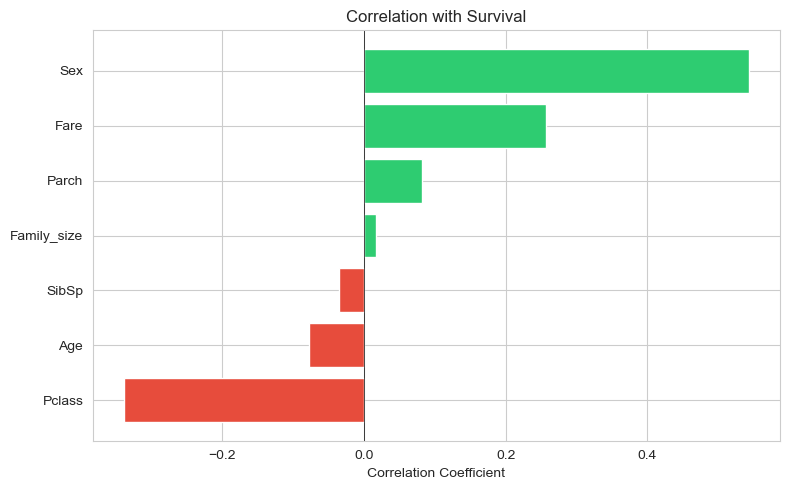

In [46]:
# Correlation with target Survived
target_corr = corr["Survived"].drop("Survived").sort_values(ascending=True)
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in target_corr.values]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.set_title("Correlation with Survival")
ax.set_xlabel("Correlation Coefficient")
ax.axvline(x=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Survival Rate by Title')

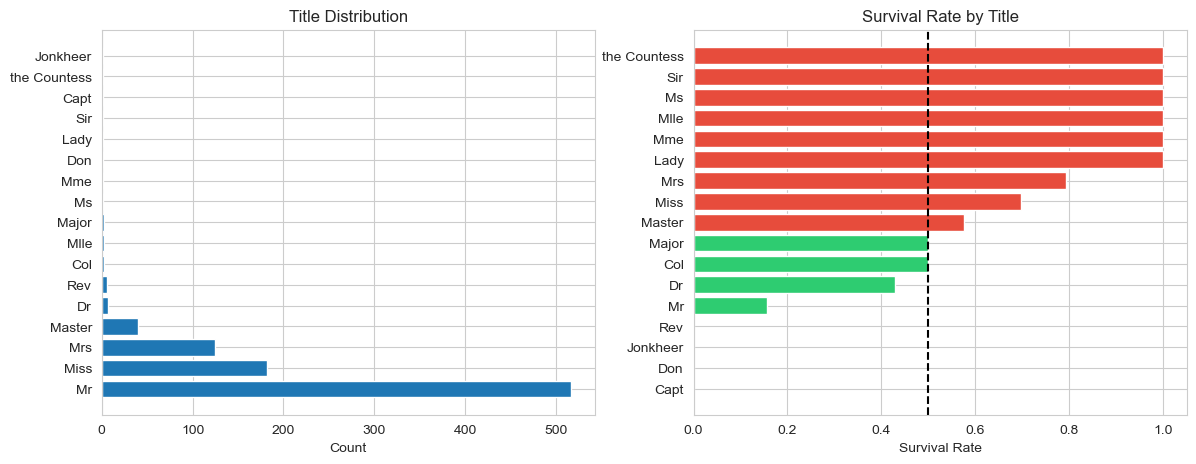

In [47]:
df["Title"] = df["Name"].apply(lambda x: x.split(",")[1].split(".")[0].strip())
survival_by_title = df.groupby("Title")["Survived"].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Title Distribution

title_counts = df["Title"].value_counts()
axes[0].barh(title_counts.index, title_counts.values)
axes[0].set_xlabel("Count")
axes[0].set_title("Title Distribution")

# Survival Rate by Title
mean_survival = df["Survived"].mean()
colors = ["#e74c3c" if rate > 0.5 else "#2ecc71" for rate in survival_by_title.values]
axes[1].barh(survival_by_title.index, survival_by_title.values, color=colors)
axes[1].axvline(x=0.5, linestyle="--", color="black")
axes[1].set_xlabel("Survival Rate")
axes[1].set_title("Survival Rate by Title")